# Refactored NV Berry-phase simulation

This notebook is the small public workflow for the simulation package. All physical constants, pulse settings, derived event times, and solver options live in `SIMULATION_PARAMETERS`.

In [19]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "simulation":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt

from simulation import (
    create_simulation_parameters,
    make_nv14_collapse_operators,
    plot_prepared_controls,
    plot_simulation_results,
    prepare_nv_simulation,
    run_prepared_simulation,
)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

## 1. Create the single shared parameter dictionary

Pass replacements through `overrides`; all dependent timing values are recalculated automatically.

In [20]:
SIMULATION_PARAMETERS = create_simulation_parameters(
    overrides={
        # Example: "B0_mT": 20.0,
        # Example: "TARGET_MW_LEG_MHZ": [0.005, 0.005, 0.005],
        "mw_loop_ramp_scale_us" : 50.,
        "loop_reporting_step_us" : 0.1
    },
    verbosity=True,
)

=========== NV Parameters ===========
B0: 20.0 mT
Nitrogen isotope: 14

========== RF/MW Parameters ==========
RF Rabi frequency: 1.5 MHz
RF phases: [0. 0.] rad
MW Rabi frequencies: [0.01 0.01 0.01] MHz
MW phases: [0. 0. 0.] rad
Detunings: [0. 0. 0.] MHz

======== Simulation Parameters ========
RF ramp time: 4.0 us
MW ramp times: [50. 50. 50.] us
Loop duration: 40.0 us
Reporting step: 0.1 us
Total time: 194.0 us



## 2. Prepare the NV, states, RF dressing, observables, and controls


[1/7] Creating the physical NV system
Created physical NV system.
  Full Hamiltonian shape: (9, 9)
  Initial-state trace: 1.0
  MW reference frequencies (MHz): [2309.50659538 3430.50396363]
  RF reference frequencies (MHz): [4.94632245 5.06837459 7.09160977 2.93152925 2.80845512 7.21366192]

[2/7] Matching the physical NV eigenstates
Matched physical NV eigenstates in (-, 0, +) order.
  Ground energies (MHz): [-4.95160977 -0.00528732 -5.07366192]
  Bare excited energies (MHz): [2302.41251228 2309.50412205 2306.5725928 ]
  Plus-manifold energies (MHz): [3427.69269452 3430.50114964 3423.28748772]
  Maximum eigenvalue/expectation mismatch (MHz): 3.097966327914037e-12

[3/7] Deriving RF and MW transition data
Derived physical transition data.
  RF e-<->e0 and e0<->e+ carriers (MHz): [7.09160977 2.93152925]
  MW g<->e carriers (MHz): [2307.36412205 2309.50940937 2311.64625472]
  RF matrix in (e-, e0, e+) basis:
 [[0.         0.99999932 0.        ]
 [0.99999932 0.         1.        ]
 [0.  

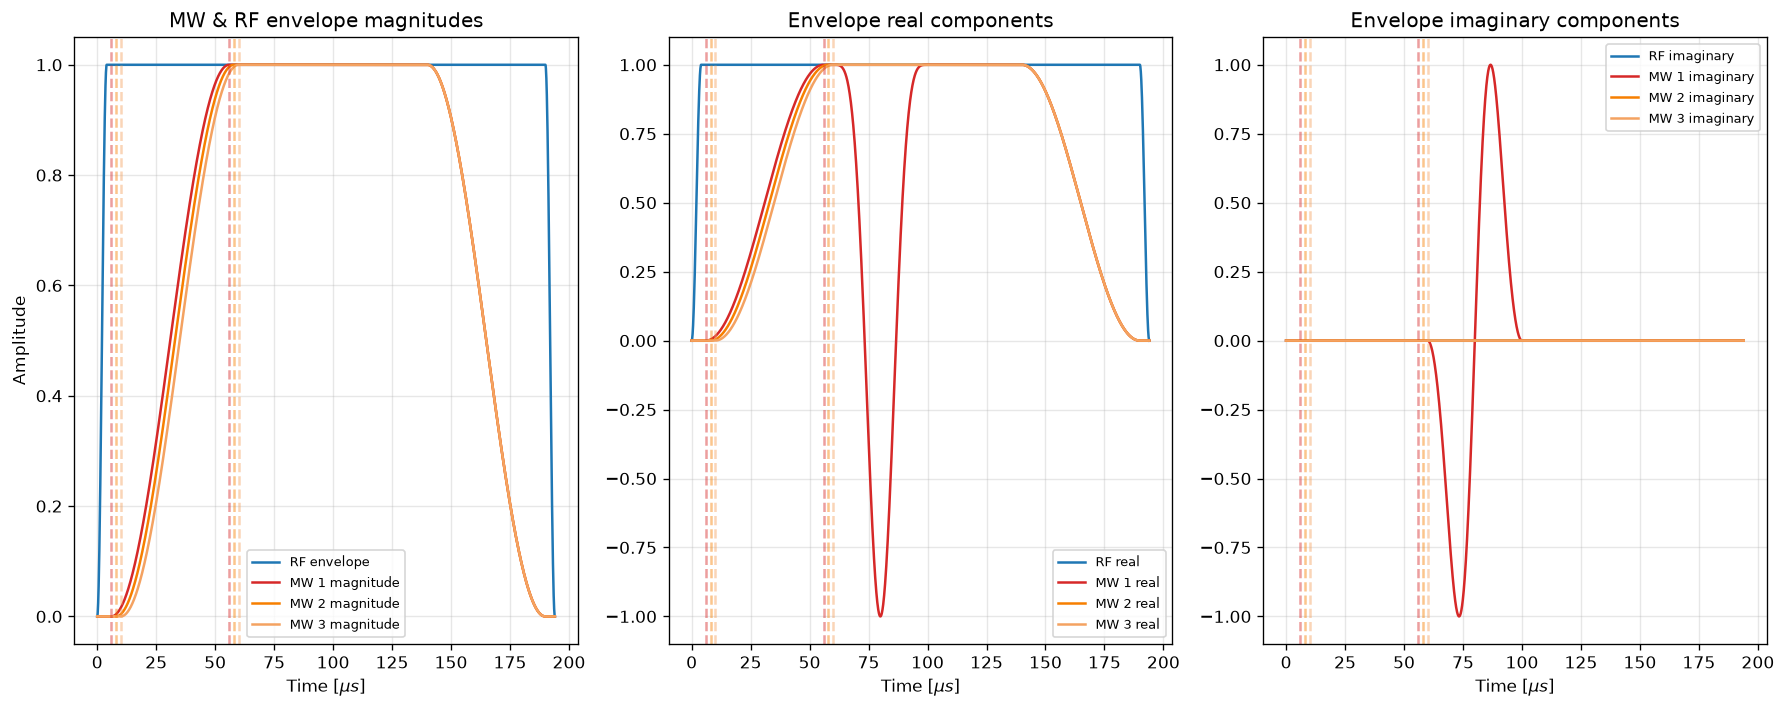

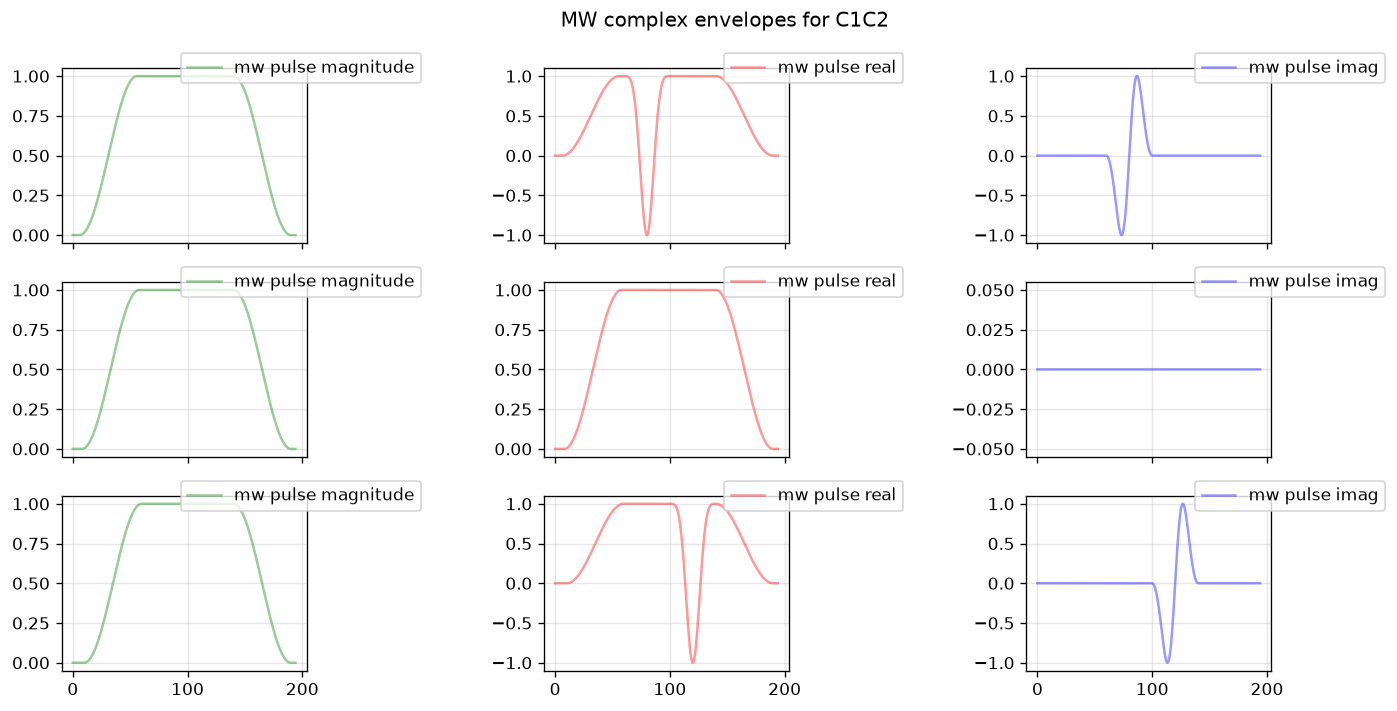

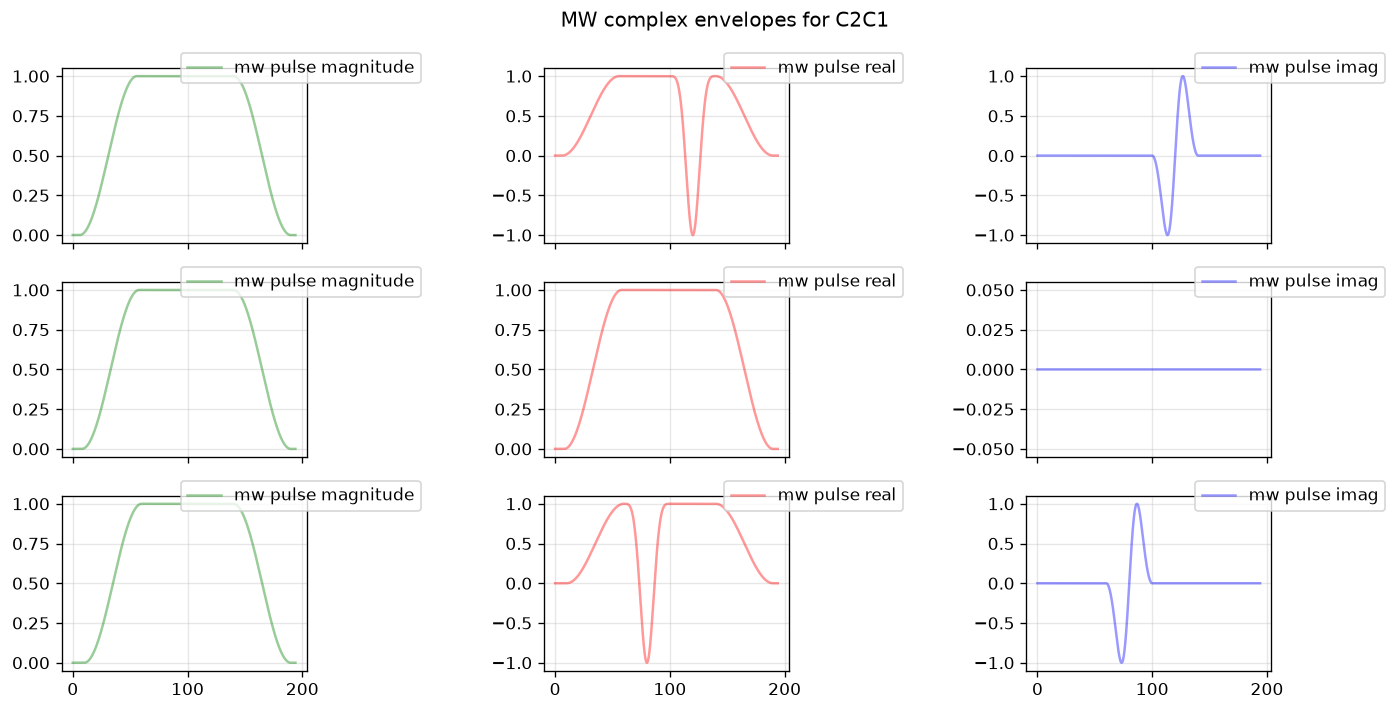

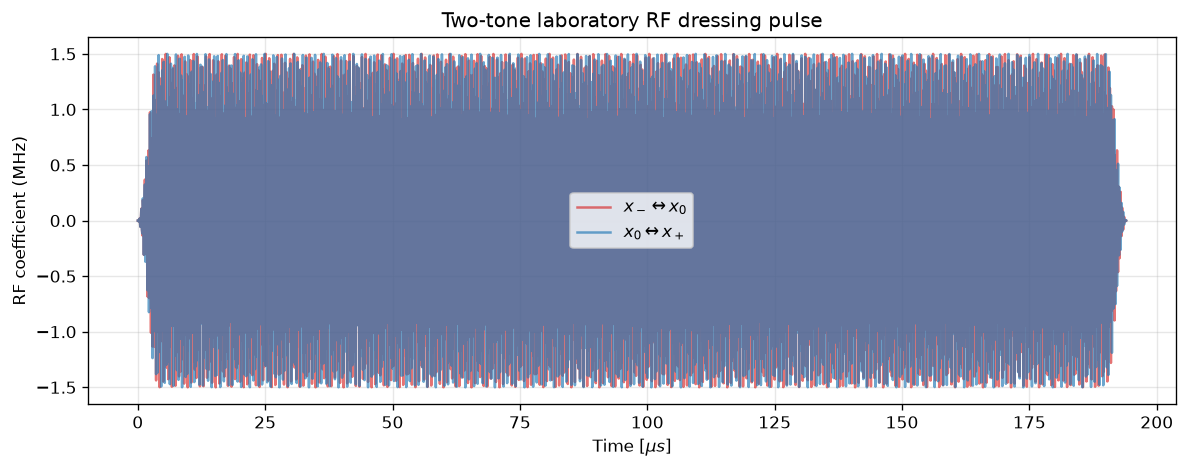

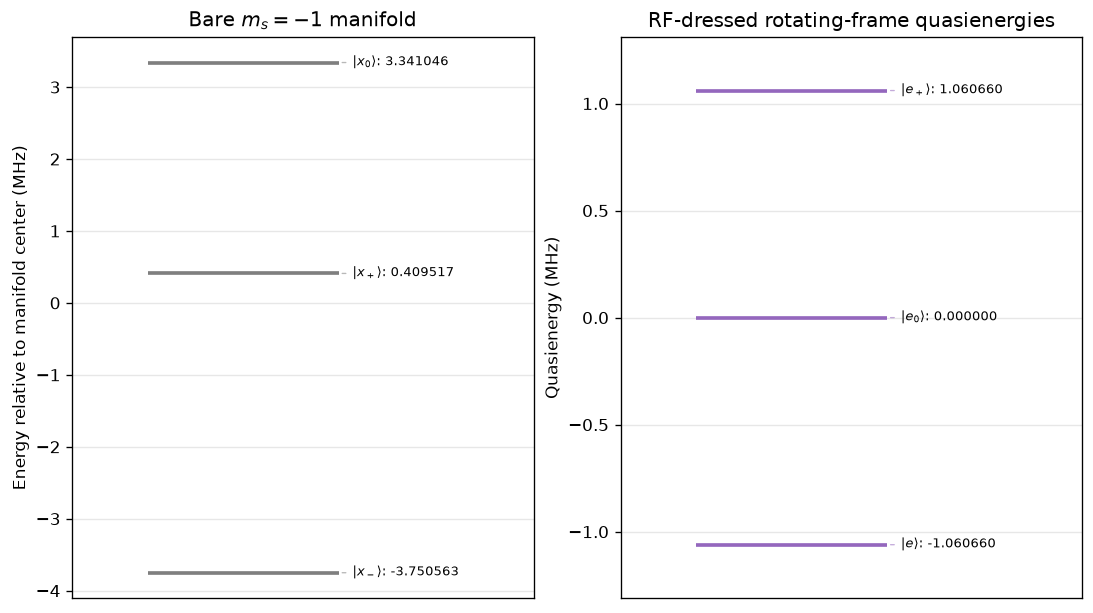

In [21]:
prepared = prepare_nv_simulation(
    SIMULATION_PARAMETERS,
    verbosity=True,
)

control_figures = plot_prepared_controls(prepared)
plt.show()

## 3. Run all loop orders

The returned dictionary always uses the order `C1C2`, `C2C1`, and `no_loops`.

In [22]:
experiments = run_prepared_simulation(
    prepared,
    collapse_operators=None,
    verbosity=True,
)

Running C1C2: 1940 intervals, 0 collapse operators.
  C1C2: completed 485/1940
  C1C2: completed 970/1940
  C1C2: completed 1455/1940
  C1C2: completed 1940/1940
  C1C2: maximum trace error = 3.331e-16
Running C2C1: 1940 intervals, 0 collapse operators.
  C2C1: completed 485/1940
  C2C1: completed 970/1940
  C2C1: completed 1455/1940
  C2C1: completed 1940/1940
  C2C1: maximum trace error = 4.441e-16
Running no_loops: 1940 intervals, 0 collapse operators.
  no_loops: completed 485/1940
  no_loops: completed 970/1940
  no_loops: completed 1455/1940
  no_loops: completed 1940/1940
  no_loops: maximum trace error = 4.441e-16
Completed all three loop-order experiments.



## 4. Recreate the population, coherence-phase, and final-state plots

Final populations for C1C2:
[1.56136971e-01 6.18369463e-01 7.42140311e-03 5.45177587e-02
 1.09036113e-01 5.45182915e-02 8.13720121e-22 1.51456770e-21
 0.00000000e+00]
  Sum: 1.000000000000
Final populations for C2C1:
[6.35485181e-01 1.29664370e-01 1.14981111e-01 2.99675856e-02
 5.99345599e-02 2.99671924e-02 4.09186539e-21 1.08526096e-21
 0.00000000e+00]
  Sum: 1.000000000000
Final populations for No Loops:
[4.78541010e-01 5.19833764e-01 4.02443387e-04 3.05709969e-04
 6.11362631e-04 3.05709721e-04 4.93426481e-21 4.54949337e-24
 0.00000000e+00]
  Sum: 1.000000000000
C1C2 - C2C1 final population difference:
 [-4.79348210e-01  4.88705093e-01 -1.07559708e-01  2.45501731e-02
  4.91015530e-02  2.45510990e-02 -3.27814527e-21  4.29306738e-22
  0.00000000e+00]


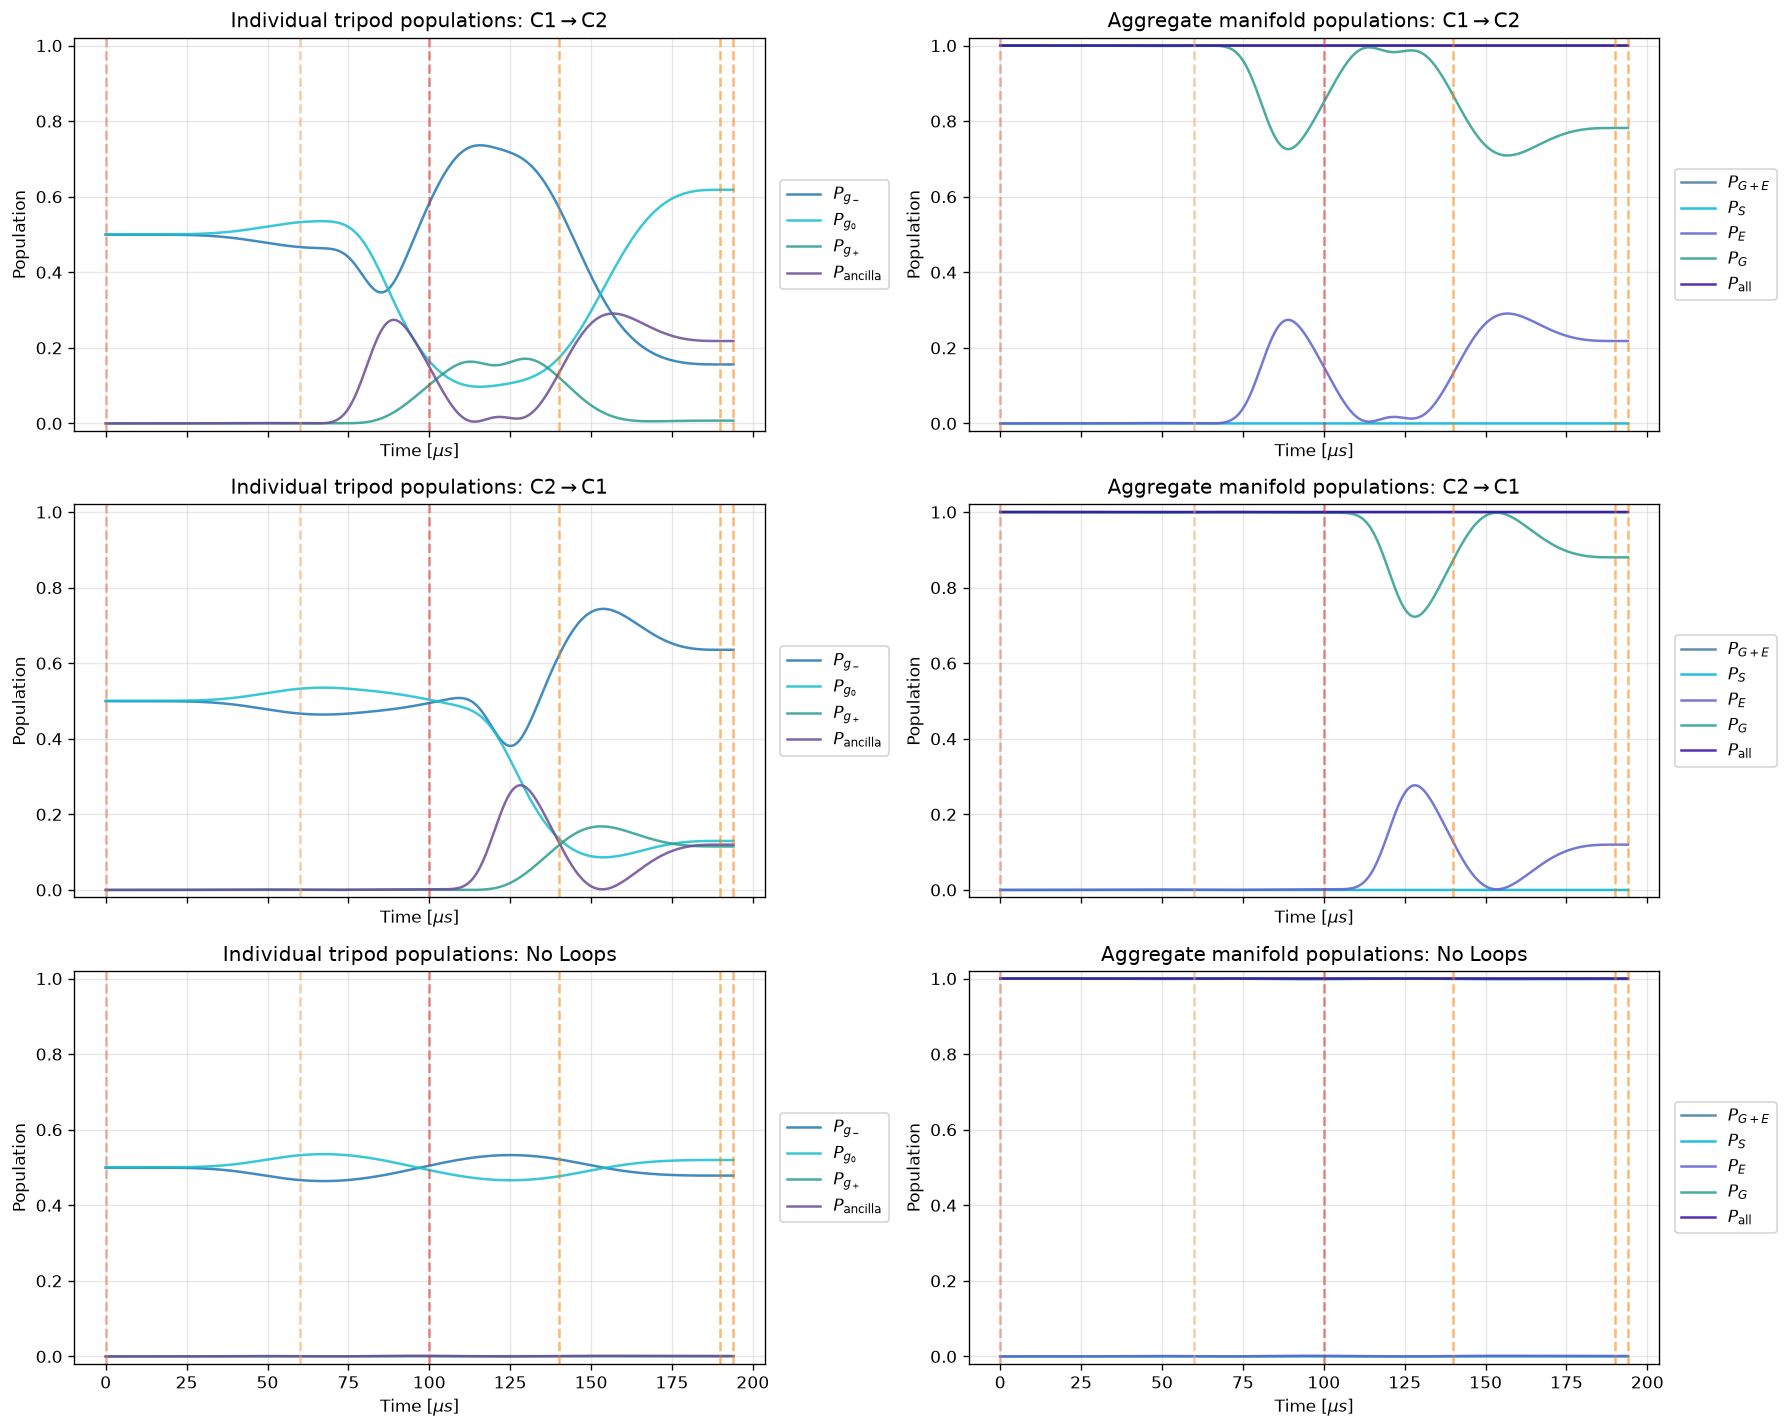

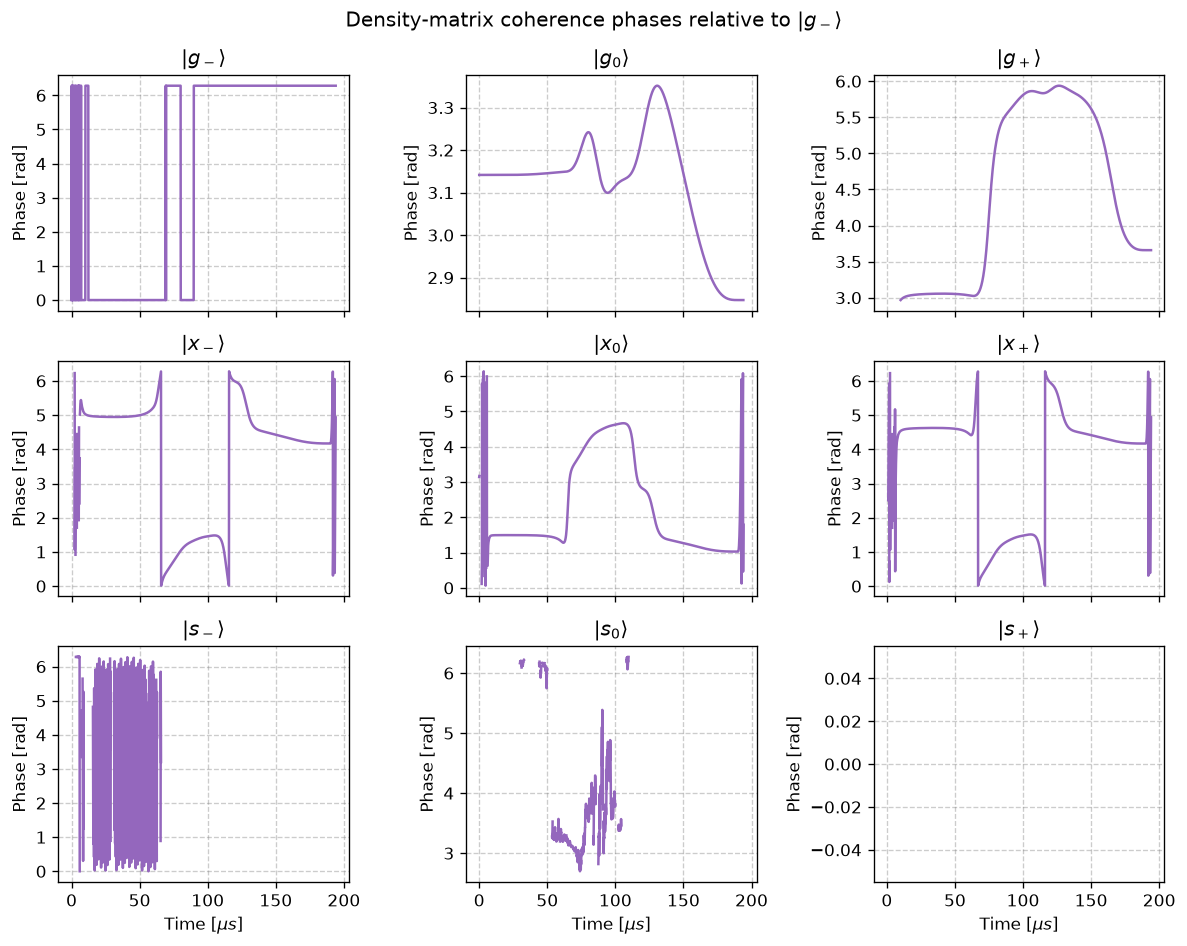

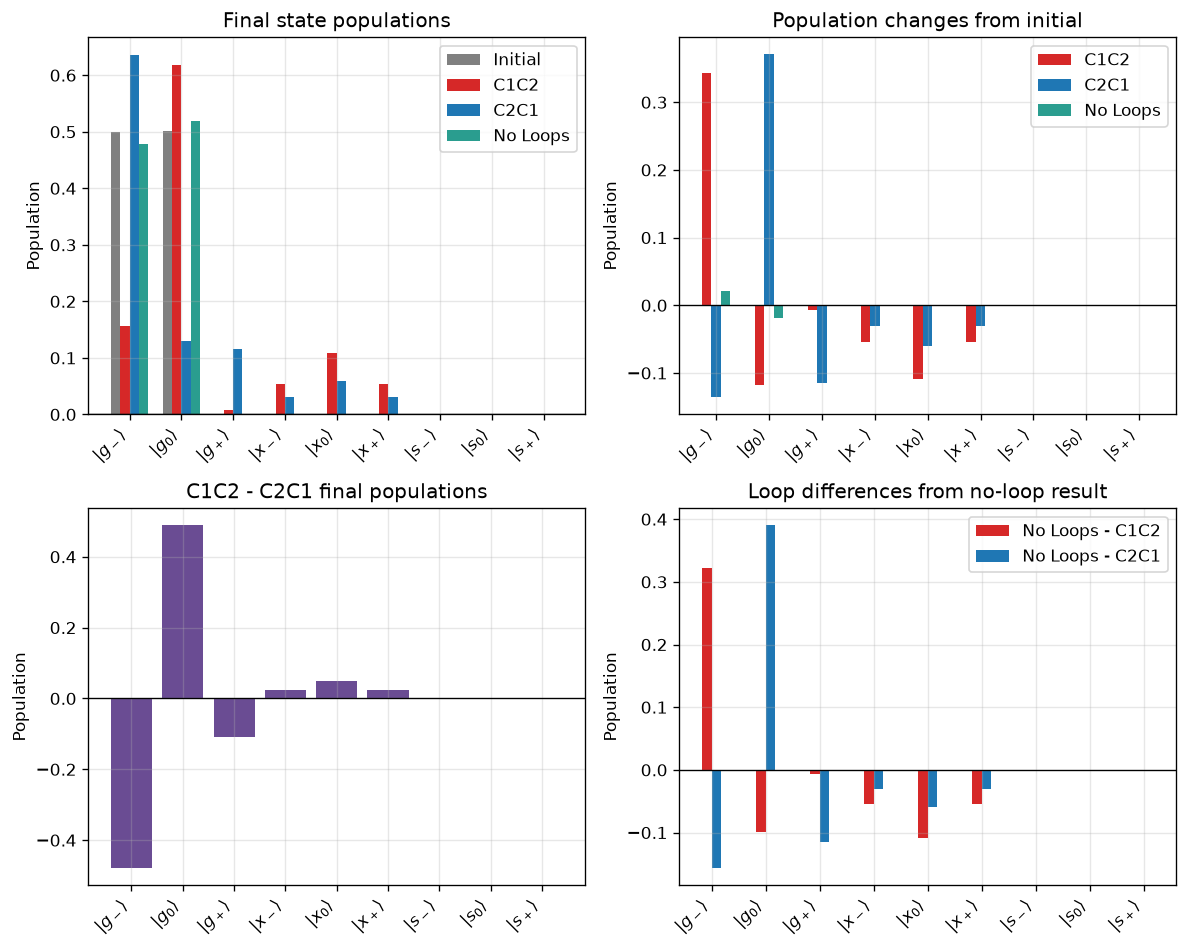

In [23]:
result_figures = plot_simulation_results(
    prepared,
    experiments,
    verbosity=True,
)
plt.show()

## Optional: repeat the same workflow with collapse operators

Set `RUN_DECOHERENCE = True` to run the same three loop orders with the electron and nuclear T1 network. The result and plotting datatypes remain identical to the closed-system run.

Constructed 24 NV-14 collapse operators.
  Electron T1: 5500.0 us
  Nuclear T1: 43000000.0 us
Running C1C2: 1940 intervals, 24 collapse operators.
  C1C2: completed 485/1940
  C1C2: completed 970/1940
  C1C2: completed 1455/1940
  C1C2: completed 1940/1940
  C1C2: maximum trace error = 4.441e-16
Running C2C1: 1940 intervals, 24 collapse operators.
  C2C1: completed 485/1940
  C2C1: completed 970/1940
  C2C1: completed 1455/1940
  C2C1: completed 1940/1940
  C2C1: maximum trace error = 4.441e-16
Running no_loops: 1940 intervals, 24 collapse operators.
  no_loops: completed 485/1940
  no_loops: completed 970/1940
  no_loops: completed 1455/1940
  no_loops: completed 1940/1940
  no_loops: maximum trace error = 3.331e-16
Completed all three loop-order experiments.

Final populations for C1C2:
[1.53510026e-01 6.05450330e-01 7.81343310e-03 5.64041742e-02
 1.09992410e-01 5.64293053e-02 5.26934497e-03 4.63541764e-03
 4.95558064e-04]
  Sum: 1.000000000000
Final populations for C2C1:
[6.21380281

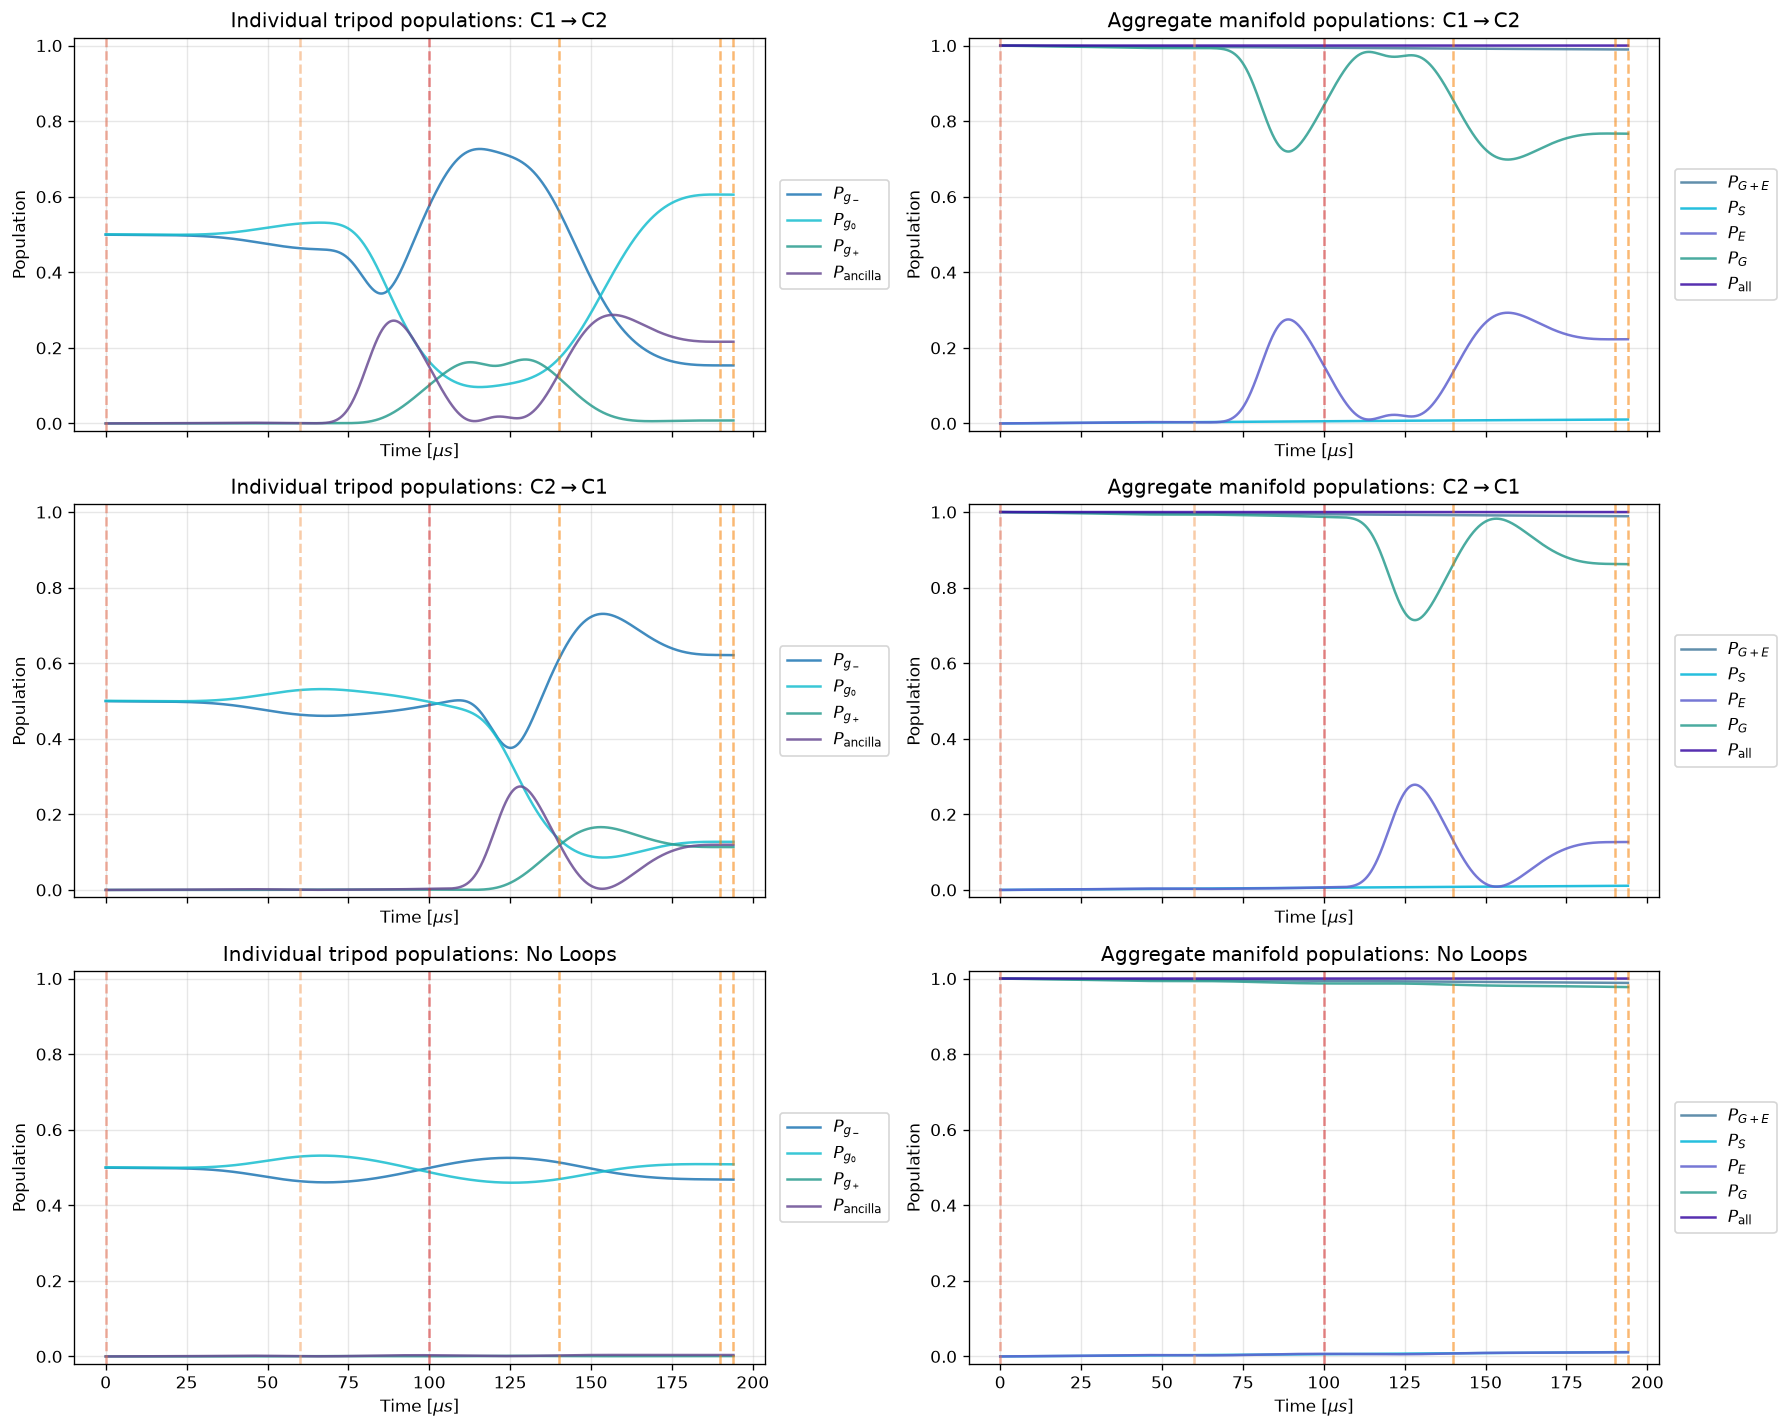

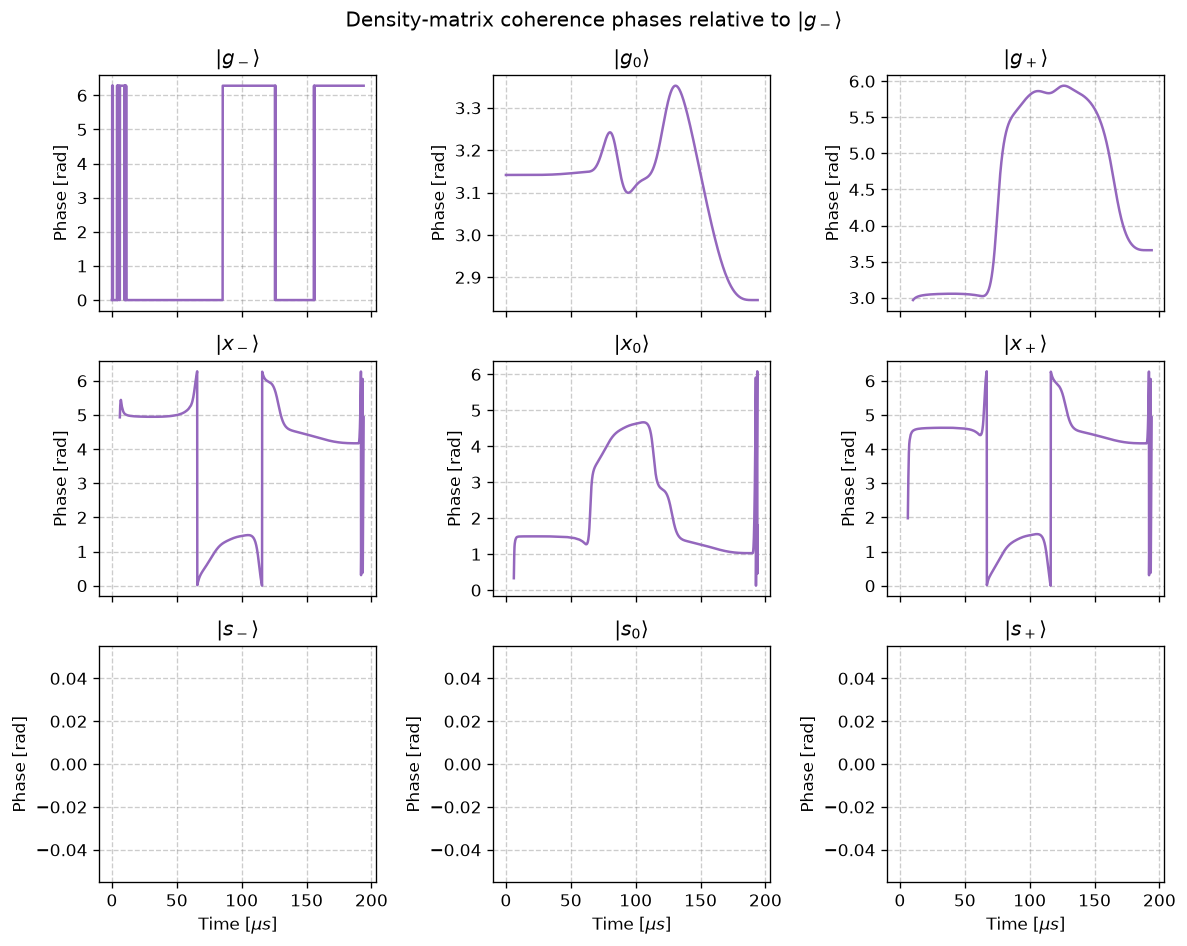

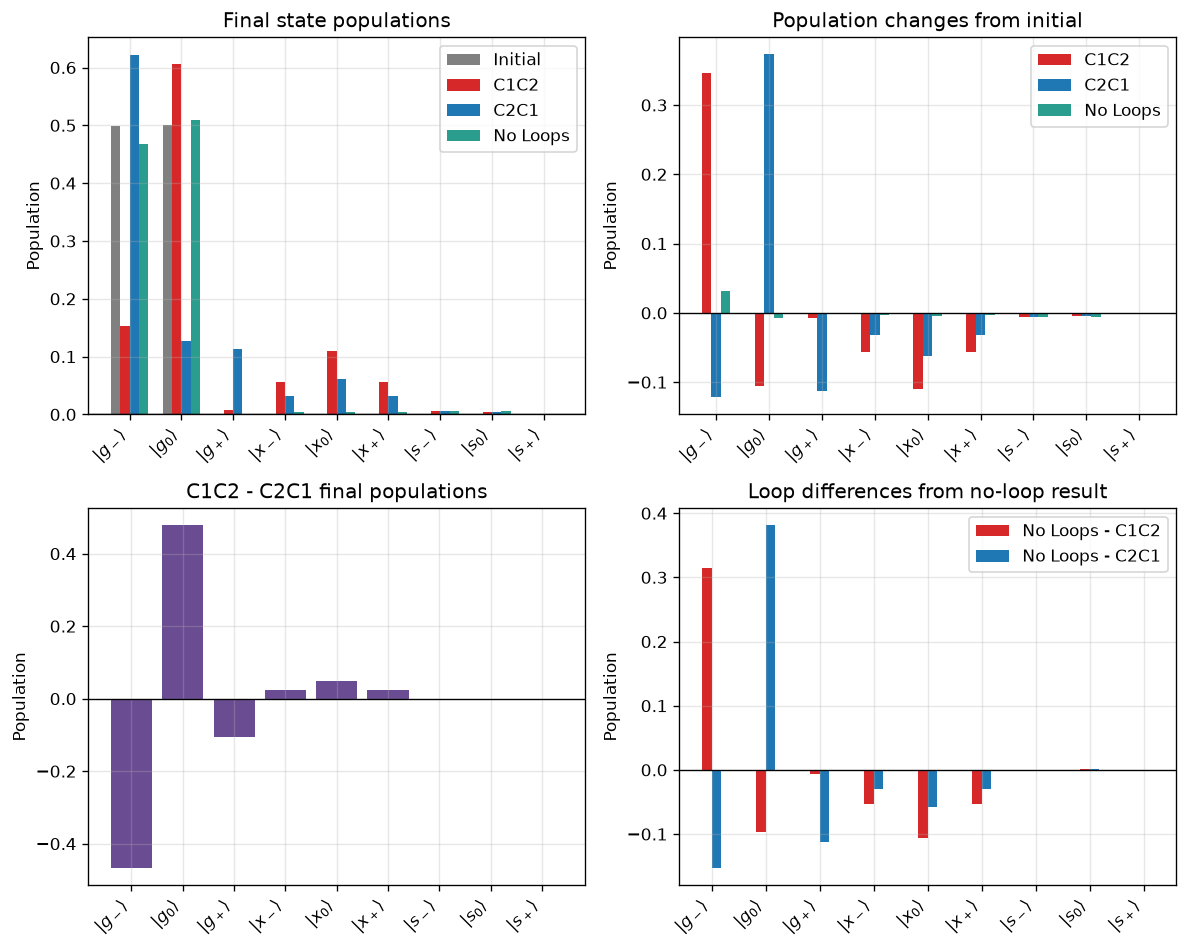

In [24]:
RUN_DECOHERENCE = True

if RUN_DECOHERENCE:
    collapse_operators = make_nv14_collapse_operators(
        prepared.states,
        SIMULATION_PARAMETERS,
        include_plus_manifold=True,
        verbosity=True,
    )
    decoherence_experiments = run_prepared_simulation(
        prepared,
        collapse_operators=collapse_operators,
        verbosity=True,
    )
    decoherence_figures = plot_simulation_results(
        prepared,
        decoherence_experiments,
        verbosity=True,
    )
    plt.show()